In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn 
import seaborn as sns

<Axes: xlabel='wt', ylabel='mpg'>

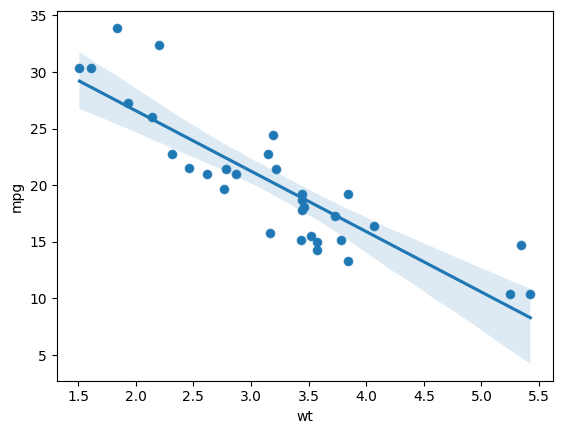

In [17]:
# data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

# visualise the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

In [18]:
# get the data
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

# convert to tensors
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

In [19]:
class LinearRegressionTorch(nn.Module):

    def __init__(self, input_size, output_size):
        # Initialize the parent class (nn.Module)
        super(LinearRegressionTorch, self).__init__()

        # Define a linear layer
        self.linear = nn.Linear(input_size, output_size)
    
    def forward(self, x):
        # Define the forward pass
        output = self.linear(x)
        return output

# set input and output sizes
input_size = 1
output_size = 1

# instantiate the model
model = LinearRegressionTorch(input_size, output_size)

In [20]:
# Specify the loss function
# We use Mean Squared Error since this is a regression problem
loss_fun = nn.MSELoss()

In [21]:
# Specify the optimizer
learning_rate = 0.01
num_epochs = 5000

# We use Stochastic Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### Optimizer

The method used to update the weights and biases of your model in order to
minimize the loss function.

<img src="figures/sgd.gif" alt="Alt text" width="500"
height="400">


In [22]:
# Do the perform training
losses, slope, bias = [], [], []
for epoch in range(num_epochs):
    
    # set gradients to zero
    optimizer.zero_grad()

    # forward pass
    y_pred = model(X)

    # calculate loss
    loss = loss_fun(y_pred, y_true)
    
    # calculate gradients
    loss.backward()

    # final step: update parameters
    optimizer.step()

    # get parameters
    for name, param in model.named_parameters():
        if param.requires_grad:
            if name == 'linear.weight':
                slope.append(param.data.numpy()[0][0])
            if name == 'linear.bias':
                bias.append(param.data.numpy()[0])


    # store loss
    losses.append(float(loss.data))


<Axes: >

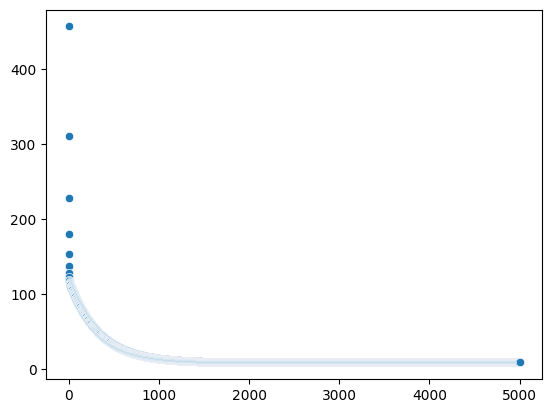

In [23]:
# print the losses over time
sns.scatterplot(x=range(num_epochs), y=losses)

<Axes: >

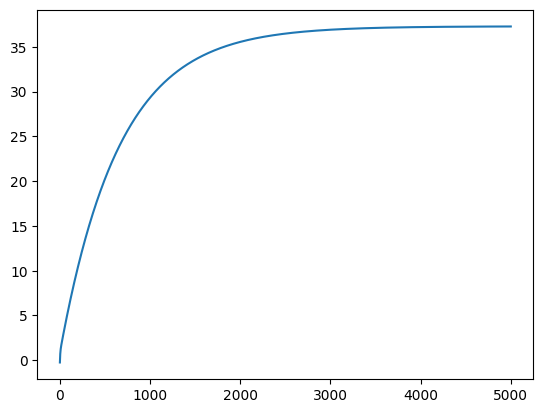

In [24]:
# visualise the bias development
sns.lineplot(x=range(num_epochs), y=bias)

<Axes: >

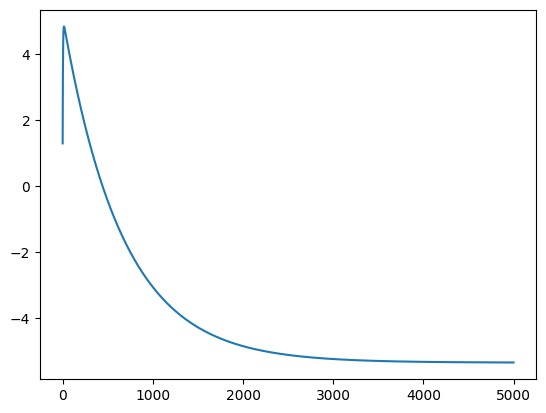

In [25]:
# visualise the slope development
sns.lineplot(x=range(num_epochs), y=slope)

<Axes: >

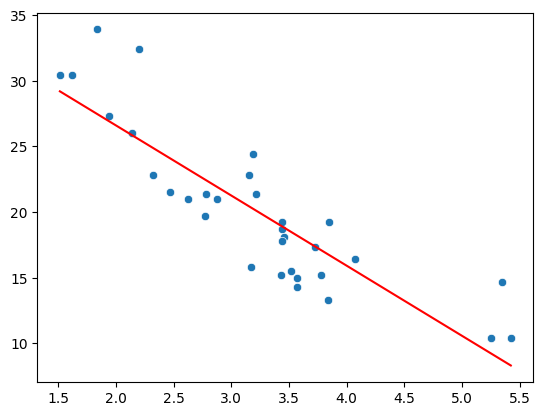

In [28]:
# plot the final model and the data
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')